In [2]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.oauth2 import service_account
import io

SCOPES = ['https://www.googleapis.com/auth/drive.readonly']
SERVICE_ACCOUNT_FILE = 'credentials.json'

creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)

service = build('drive', 'v3', credentials=creds)

folder_id = '1BoaRum8pO-ITELHTcsrX5Fhsxmv3VeLX'

files = service.files().list(
    q=f"'{folder_id}' in parents and trashed=false",
    fields="files(id, name, mimeType)"
).execute()['files']

parquet_files = [f for f in files if f['name'].endswith('.parquet ')]
file_id = files[0]['id']  # or sort if needed

# download + read
request = service.files().get_media(fileId=file_id)
fh = io.BytesIO()

downloader = MediaIoBaseDownload(fh, request)
done = False
while not done:
    _, done = downloader.next_chunk()

fh.seek(0)

0

In [4]:
import pandas as pd
df = pd.read_parquet(fh)

In [5]:
print(f'{df.shape=}')
df.isna().sum()

df.shape=(3724889, 20)


VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [6]:
df[["tpep_pickup_datetime", "tpep_dropoff_datetime"]][:2]

,tpep_pickup_datetime,tpep_dropoff_datetime
0,2026-01-01 00:54:04,2026-01-01 00:59:37
1,2026-01-01 00:34:04,2026-01-01 00:39:47


In [10]:
df_new = df.copy()
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

### ✅ 1. Time Series Construction
Demand = number of pickups per 15-min interval 
At least:
city-wide
3–5 key zones

1. groupby pickup location


In [11]:
df_new.groupby(["PULocationID", "tpep_pickup_datetime"]).count()

VendorID  tpep_dropoff_datetime  \
PULocationID tpep_pickup_datetime                                    
1            2026-01-01 02:30:45          1                      1   
             2026-01-01 04:08:39          1                      1   
             2026-01-01 04:49:25          1                      1   
             2026-01-01 04:53:06          1                      1   
             2026-01-01 05:26:51          1                      1   
...                                     ...                    ...   
265          2026-01-31 22:04:35          1                      1   
             2026-01-31 22:05:11          1                      1   
             2026-01-31 22:16:10          1                      1   
             2026-01-31 22:33:00          1                      1   
             2026-01-31 22:59:18          1                      1   

                                   passenger_count  trip_distance  RatecodeID  \
PULocationID tpep_pickup_datetime                                               
1            2026-01-01 02:30:45                 1              1           1   
             2026-01-01 04:08:39                 1              1           1   
             2026-01-01 04:49:25                 1              1           1   
             2026-01-01 04:53:06                 1              1           1   
             2026-01-01 05:26:51                 1              1           1   
...                                            ...            ...         ...   
265          2026-01-31 22:04:35                 1              1           1   
             2026-01-31 22:05:11                 1              1           1   
             2026-01-31 22:16:10                 1              1           1   
             2026-01-31 22:33:00                 1              1           1   
             2026-01-31 22:59:18                 1              1           1   

                                   store_and_fwd_flag  DOLocationID  \
PULocationID tpep_pickup_datetime                                     
1            2026-01-01 02:30:45                    1             1   
             2026-01-01 04:08:39                    1             1   
             2026-01-01 04:49:25                    1             1   
             2026-01-01 04:53:06                    1             1   
             2026-01-01 05:26:51                    1             1   
...                                               ...           ...   
265          2026-01-31 22:04:35                    1             1   
             2026-01-31 22:05:11                    1             1   
             2026-01-31 22:16:10                    1             1   
             2026-01-31 22:33:00                    1             1   
             2026-01-31 22:59:18                    1             1   

                                   payment_type  fare_amount  extra  mta_tax  \
PULocationID tpep_pickup_datetime                                              
1            2026-01-01 02:30:45              1            1      1        1   
             2026-01-01 04:08:39              1            1      1        1   
             2026-01-01 04:49:25              1            1      1        1   
             2026-01-01 04:53:06              1            1      1        1   
             2026-01-01 05:26:51              1            1      1        1   
...                                         ...          ...    ...      ...   
265          2026-01-31 22:04:35              1            1      1        1   
             2026-01-31 22:05:11              1            1      1        1   
             2026-01-31 22:16:10              1            1      1        1   
             2026-01-31 22:33:00              1            1      1        1   
             2026-01-31 22:59:18              1            1      1        1   

                                   tip_amount  tolls_amount  \
PULocationID tpep_pickup_datetime         

In [16]:
cols = ["tpep_pickup_datetime", "tpep_dropoff_datetime"]
df_new[cols] = df_new[cols].apply(pd.to_datetime, format="%Y-%m-%d %H:%M:%S")

In [23]:
df_new["tpep_pickup_datetime_floor"] = df_new['tpep_pickup_datetime'].dt.floor('15T')


C:\Users\drish\AppData\Local\Temp\ipykernel_19716\3372360033.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_new["tpep_pickup_datetime_floor"] = df_new['tpep_pickup_datetime'].dt.floor('15T')


In [21]:
df_new["tpep_pickup_datetime"]

0         2026-01-01 00:54:04
1         2026-01-01 00:34:04
2         2026-01-01 00:57:06
3         2026-01-01 00:15:22
4         2026-01-01 00:27:13
                  ...        
3724884   2026-01-31 23:26:00
3724885   2026-01-31 23:33:53
3724886   2026-01-31 23:40:23
3724887   2026-01-31 23:10:21
3724888   2026-01-31 23:43:12
Name: tpep_pickup_datetime, Length: 3724889, dtype: datetime64[us]

In [109]:
df_new

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,tpep_pickup_datetime_floor
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,2026-01-01 00:45:00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75,2026-01-01 00:30:00
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75,2026-01-01 00:45:00
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,2026-01-01 00:15:00
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75,2026-01-01 00:15:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,None,237,161,0,...,0.00,0.5,0.00,0.0,1.0,21.84,NaN,NaN,0.75,2026-01-31 23:15:00
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,None,42,42,0,...,0.00,0.5,0.00,0.0,1.0,24.69,NaN,NaN,0.00,2026-01-31 23:30:00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,None,137,69,0,...,0.00,0.5,0.00,0.0,1.0,33.96,NaN,NaN,0.75,2026-01-31 23:30:00
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,None,137,162,0,...,0.00,0.5,0.00,0.0,1.0,23.94,NaN,NaN,0.75,2026-01-31 23:00:00


In [110]:
df_new.groupby(["PULocationID", "tpep_pickup_datetime_floor"]).size()


PULocationID  tpep_pickup_datetime_floor
1             2026-01-01 02:30:00           1
              2026-01-01 04:00:00           1
              2026-01-01 04:45:00           2
              2026-01-01 05:15:00           2
              2026-01-01 05:30:00           3
                                           ..
265           2026-01-31 21:30:00           1
              2026-01-31 22:00:00           3
              2026-01-31 22:15:00           1
              2026-01-31 22:30:00           1
              2026-01-31 22:45:00           1
Length: 332999, dtype: int64

In [111]:
df_new['tpep_pickup_datetime_floor']

0         2026-01-01 00:45:00
1         2026-01-01 00:30:00
2         2026-01-01 00:45:00
3         2026-01-01 00:15:00
4         2026-01-01 00:15:00
                  ...        
3724884   2026-01-31 23:15:00
3724885   2026-01-31 23:30:00
3724886   2026-01-31 23:30:00
3724887   2026-01-31 23:00:00
3724888   2026-01-31 23:30:00
Name: tpep_pickup_datetime_floor, Length: 3724889, dtype: datetime64[us]

In [159]:
city = df_new.groupby('tpep_pickup_datetime_floor').size()

In [160]:
city = city.sort_index()

In [161]:
full_index = pd.date_range(
    start=city.index.min(),
    end=city.index.max(),
    freq='15min'
)
city = city.reindex(full_index, fill_value=0)

In [162]:
city = city.to_frame(name='demand')

In [163]:
city['hour'] = city.index.hour
city['day_of_week'] = city.index.dayofweek
city['is_weekend'] = (city.index.dayofweek >= 5).astype(bool)
city["hour"] = city.index.hour
city['time_of_day'] = city.index.hour * 60 + city.index.minute

In [164]:
city

,demand,hour,day_of_week,is_weekend,time_of_day
2025-12-31 23:45:00,6,23,2,False,1425
2026-01-01 00:00:00,1432,0,3,False,0
2026-01-01 00:15:00,2610,0,3,False,15
2026-01-01 00:30:00,2674,0,3,False,30
2026-01-01 00:45:00,2578,0,3,False,45
...,...,...,...,...,...
2026-01-31 23:45:00,2095,23,5,True,1425
2026-02-01 00:00:00,0,0,6,True,0
2026-02-01 00:15:00,0,0,6,True,15
2026-02-01 00:30:00,0,0,6,True,30


<Axes: title={'center': 'Weekend Demand by Hour'}, xlabel='hour'>

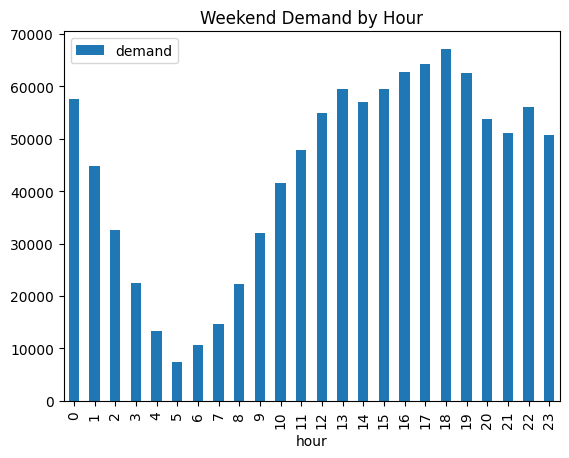

In [169]:
city[city["is_weekend"] == True][["hour", "demand"]].groupby(["hour"]).sum().plot(kind='bar', title="Weekend Demand by Hour")

<Axes: title={'center': 'Weekday Demand by Hour'}, xlabel='hour'>

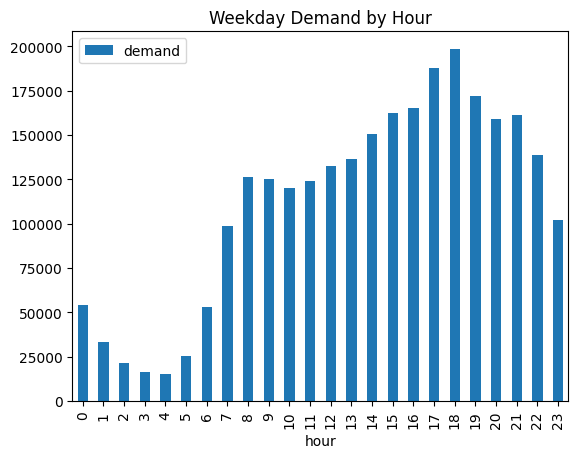

In [170]:
city[city["is_weekend"] == False][["hour", "demand"]].groupby(["hour"]).sum().plot(kind='bar', title="Weekday Demand by Hour")

<Axes: title={'center': 'Mean demand by hour on weekend'}, xlabel='hour'>

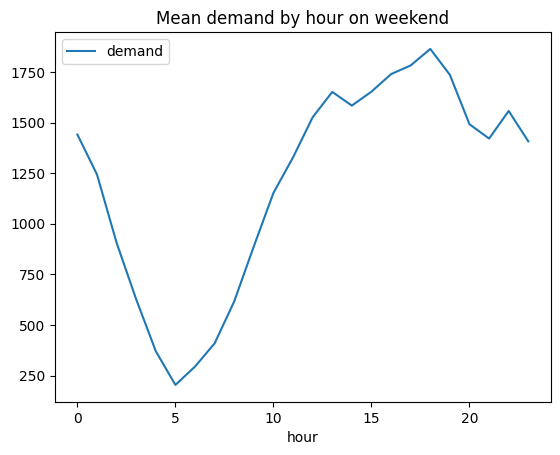

In [172]:
city[city["is_weekend"] == True][["hour", "demand"]].groupby(["hour"]).mean().plot(kind = "line", title = "Mean demand by hour on weekend")

<Axes: title={'center': 'Mean demand by hour on weekdays'}, xlabel='hour'>

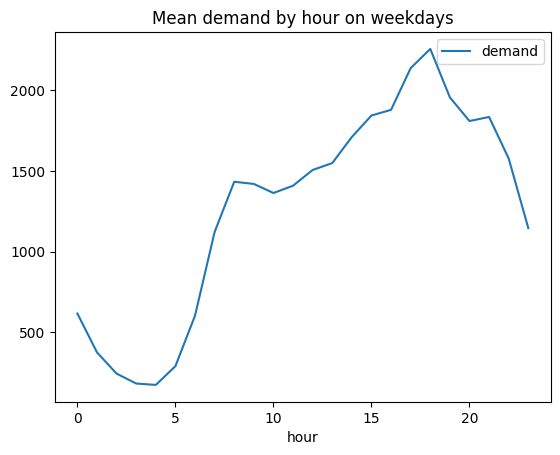

In [173]:
city[city["is_weekend"] == False][["hour", "demand"]].groupby(["hour"]).mean().plot(kind = "line", title = "Mean demand by hour on weekdays")

<Axes: title={'center': 'Standard Deviation of Demand by Hour'}, xlabel='hour'>

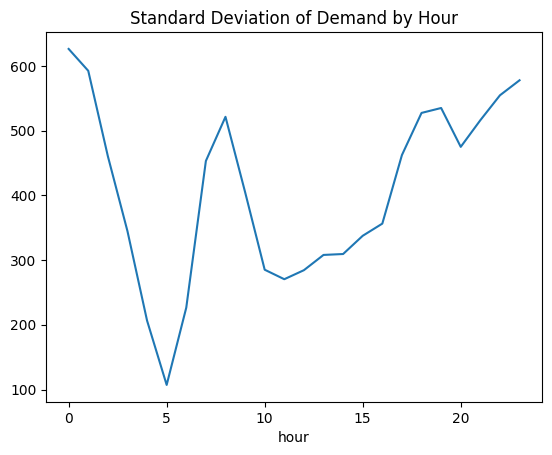

In [175]:
city.groupby('hour')['demand'].std().plot(kind='line', title='Standard Deviation of Demand by Hour')

<Axes: title={'center': 'Variance of Demand by Hour'}, xlabel='hour'>

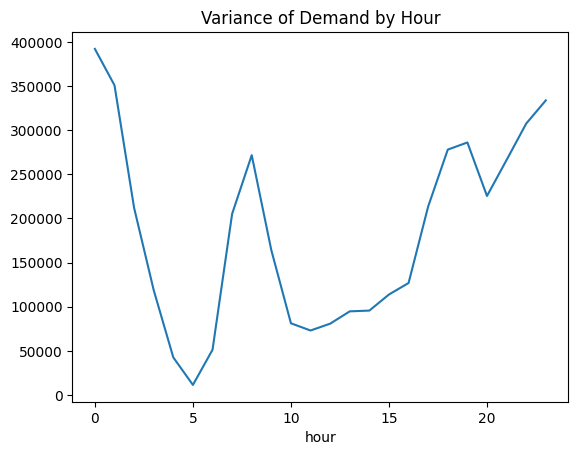

In [176]:
city.groupby('hour')['demand'].var().plot(kind='line', title='Variance of Demand by Hour')

In [177]:
city["predict"] = city["demand"].shift(96)
city_model = city.dropna()

In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(city_model['demand'], city_model['predict'])
rmse = np.sqrt(mean_squared_error(city_model['demand'], city_model['predict']))

In [180]:
print(mae)
print(rmse)

280.37538994800695
452.52938240635217


In [182]:
city_model['hour'] = city_model.index.hour
error_by_hour = city_model.groupby('hour').apply(
    lambda x: mean_absolute_error(x['demand'], x['predict'])
)

C:\Users\drish\AppData\Local\Temp\ipykernel_19716\928932469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_model['hour'] = city_model.index.hour
C:\Users\drish\AppData\Local\Temp\ipykernel_19716\928932469.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_by_hour = city_model.groupby('hour').apply(


<Axes: title={'center': 'Error by hour'}, xlabel='hour'>

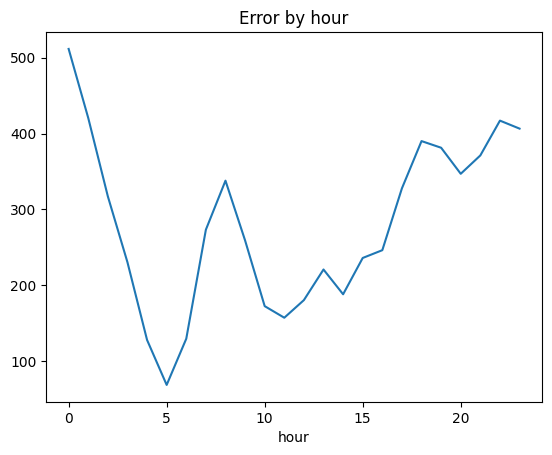

In [185]:
error_by_hour.plot(kind = "line", title = "Error by hour")

In [187]:
print(f'{error_by_hour.std()=}')
print(f'{error_by_hour.var()=}')

error_by_hour.std()=np.float64(113.29167449710938)
error_by_hour.var()=np.float64(12835.003510358983)


In [188]:
avg_profile = city.groupby(['day_of_week', 'hour'])['demand'].mean()

In [197]:
city['expected'] =city.groupby(['day_of_week', 'hour'])['demand'].transform('mean')
city['residual'] = city['demand'] - city['expected']

<Axes: title={'center': 'Residual std over hours'}, xlabel='hour'>

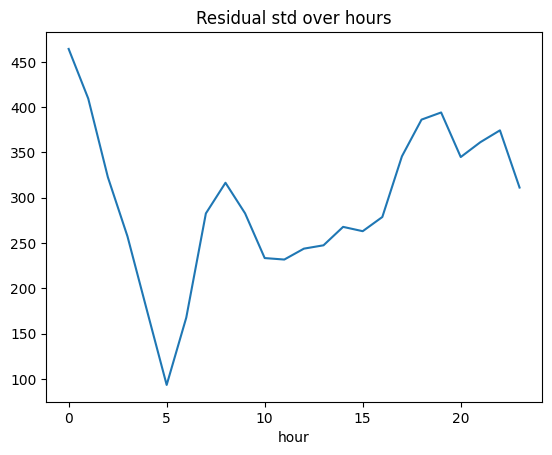

In [201]:
city.groupby('hour')['residual'].std().plot(kind = "line", title= "Residual std over hours")

day_of_week  hour
0            0        487.5000
             1        242.5625
             2        147.3125
             3        108.6250
             4        127.3750
                       ...    
6            19      1190.5625
             20      1059.0000
             21       989.3125
             22       950.9375
             23       745.4375
Name: demand, Length: 168, dtype: float64